# Quantifying Data Quality: A Statistical Framework for Scoring and Monitoring Scientific Datasets
 
##Nikhilvarma Kandula 
 
Dataset: UCI Air Quality (De Vito, 2016) — [https://doi.org/10.24432/C59K5F](https://doi.org/10.24432/C59K5F)

## 1. Setup & Libraries

Importing the required Python libraries for data manipulation, visualization, and statistical analysis. Setting up a consistent color scheme for all plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# plot settings
ACCENT = '#00C6B2'
BLACK = '#1a1a1a'
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.edgecolor'] = BLACK
plt.rcParams['text.color'] = BLACK
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)


## 2. Loading the Dataset

The UCI Air Quality dataset contains 9,358 hourly averaged sensor readings collected from March 2004 to February 2005 in an Italian city (De Vito, 2016). The CSV uses semicolon separators and commas as decimal points.

In [2]:
# load the UCI air quality dataset
# source: De Vito, S. (2016). Air Quality. UCI ML Repository
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

# the csv has trailing semicolons which create empty columns
df = df.dropna(axis=1, how='all')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Shape: (9471, 15)
Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


### 2.1 DateTime Conversion & Missing Value Handling

The dataset uses `-200` to indicate missing or faulty sensor readings (documented in the UCI repository). These need to be replaced with `NaN` before any analysis.

In [3]:
# combine date and time into a proper datetime column
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')

# per UCI docs, -200 means missing/sensor error
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols] = df[numeric_cols].replace(-200, np.nan)

print(f"Time range: {df['DateTime'].min()} to {df['DateTime'].max()}")
print(f"Records: {len(df)}")


Time range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Records: 9471


### 2.2 Missing Value Analysis

Checking the extent of missing data across all columns to decide which variables are usable and which need to be dropped.

In [4]:
# check how much data is actually missing
missing_pct = (df[numeric_cols].isnull().sum() / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'missing_count': df[numeric_cols].isnull().sum(),
    'missing_pct': missing_pct,
    'valid': df[numeric_cols].notnull().sum()
}).sort_values('missing_pct', ascending=False)

print(missing_summary)


               missing_count  missing_pct  valid
NMHC(GT)                8557        90.35    914
CO(GT)                  1797        18.97   7674
NO2(GT)                 1756        18.54   7715
NOx(GT)                 1753        18.51   7718
PT08.S1(CO)              480         5.07   8991
C6H6(GT)                 480         5.07   8991
PT08.S2(NMHC)            480         5.07   8991
PT08.S3(NOx)             480         5.07   8991
PT08.S4(NO2)             480         5.07   8991
PT08.S5(O3)              480         5.07   8991
T                        480         5.07   8991
RH                       480         5.07   8991
AH                       480         5.07   8991


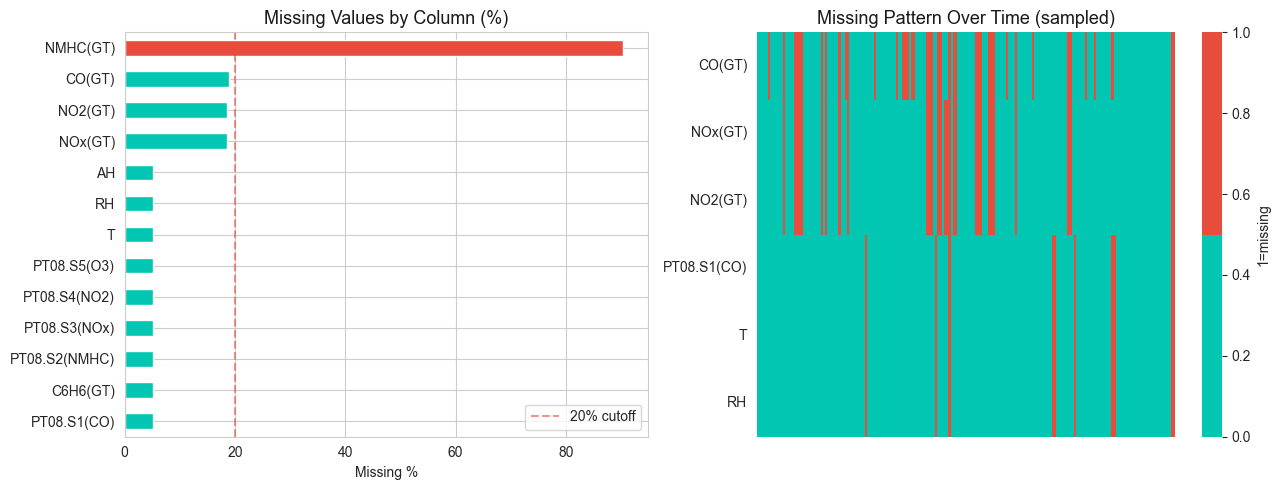

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# bar chart of missing %
missing_sorted = missing_pct.sort_values(ascending=True)
bar_colors = [ACCENT if x < 20 else '#e74c3c' for x in missing_sorted.values]
missing_sorted.plot(kind='barh', ax=axes[0], color=bar_colors)
axes[0].set_title('Missing Values by Column (%)', fontsize=13, color=BLACK)
axes[0].set_xlabel('Missing %')
axes[0].axvline(x=20, color='#e74c3c', linestyle='--', alpha=0.6, label='20% cutoff')
axes[0].legend()

# heatmap showing missing pattern over time
sample_cols = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'PT08.S1(CO)', 'T', 'RH']
miss_matrix = df[sample_cols].isnull().astype(int).iloc[::50]  # sample every 50th row
sns.heatmap(miss_matrix.T, cbar_kws={'label': '1=missing'}, 
            cmap=[ACCENT, '#e74c3c'], ax=axes[1],
            yticklabels=True, xticklabels=False)
axes[1].set_title('Missing Pattern Over Time (sampled)', fontsize=13, color=BLACK)

plt.tight_layout()
plt.savefig('fig_01_missing_data.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Data Cleaning

Three steps: (1) drop columns with too much missing data, (2) remove completely empty rows, (3) detect outliers using both IQR and z-score methods. Outliers are flagged but kept — removing extreme sensor readings would bias the quality assessment since they may reflect real environmental events.

In [6]:
# --- Data Cleaning ---

sensor_cols = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
               'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 
               'PT08.S5(O3)', 'T', 'RH', 'AH']

# drop NMHC(GT) because 90% is missing - cant do anything with it
df_clean = df.drop(columns=['NMHC(GT)'])
print(f"Dropped NMHC(GT) - 90% missing")

# drop rows where every sensor value is NaN
before = len(df_clean)
df_clean = df_clean.dropna(subset=sensor_cols, how='all')
print(f"Removed {before - len(df_clean)} completely empty rows")

# outlier check with IQR
print("\nOutlier detection (IQR method):")
for col in sensor_cols:
    d = df_clean[col].dropna()
    Q1, Q3 = d.quantile(0.25), d.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((d < Q1 - 1.5*IQR) | (d > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        print(f"  {col}: {n_out} outliers ({n_out/len(d)*100:.1f}%)")

# keeping outliers - they could be real environmental events
# removing them would bias our quality assessment
print(f"\nDecision: outliers flagged but NOT removed")

# also checking z-scores for extreme values
print("\nExtreme values (|z| > 3):")
for col in sensor_cols:
    d = df_clean[col].dropna()
    z = np.abs(stats.zscore(d))
    n_extreme = (z > 3).sum()
    if n_extreme > 0:
        print(f"  {col}: {n_extreme}")

print(f"\nFinal dataset: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")


Dropped NMHC(GT) - 90% missing
Removed 145 completely empty rows

Outlier detection (IQR method):
  CO(GT): 215 outliers (2.8%)
  PT08.S1(CO): 118 outliers (1.3%)
  C6H6(GT): 228 outliers (2.5%)
  PT08.S2(NMHC): 65 outliers (0.7%)
  NOx(GT): 435 outliers (5.6%)
  PT08.S3(NOx): 241 outliers (2.7%)
  NO2(GT): 107 outliers (1.4%)
  PT08.S4(NO2): 97 outliers (1.1%)
  PT08.S5(O3): 93 outliers (1.0%)
  T: 3 outliers (0.0%)
  AH: 2 outliers (0.0%)

Decision: outliers flagged but NOT removed

Extreme values (|z| > 3):
  CO(GT): 102
  PT08.S1(CO): 60
  C6H6(GT): 118
  PT08.S2(NMHC): 37
  NOx(GT): 138
  PT08.S3(NOx): 109
  NO2(GT): 48
  PT08.S4(NO2): 38
  PT08.S5(O3): 37

Final dataset: 9326 rows x 15 columns


## 4. Data Quality Dimensions

We operationalize four DQ dimensions from the literature (Wang & Strong, 1996; Pipino et al., 2002; Batini & Scannapieco, 2016; Heinrich et al., 2018) and score each on a 0–1 scale.

### 4.1 Completeness

**Formula:** `1 − (missing / total)` per column  
**Source:** Pipino et al. (2002)  
Measures the proportion of non-null values. A score of 1.0 means no missing data.

In [7]:
# --- DIMENSION 1: COMPLETENESS ---
# formula: 1 - (missing / total) per column
# based on Pipino et al. (2002)

completeness_scores = {}
for col in sensor_cols:
    total = len(df_clean)
    missing = df_clean[col].isnull().sum()
    completeness_scores[col] = 1 - (missing / total)

print("Completeness scores per column:")
for col, score in completeness_scores.items():
    print(f"  {col:<18} {score:.4f}")

overall_completeness = np.mean(list(completeness_scores.values()))
print(f"\nOverall completeness: {overall_completeness:.4f}")


Completeness scores per column:
  CO(GT)             0.8229
  PT08.S1(CO)        0.9641
  C6H6(GT)           0.9641
  PT08.S2(NMHC)      0.9641
  NOx(GT)            0.8276
  PT08.S3(NOx)       0.9641
  NO2(GT)            0.8273
  PT08.S4(NO2)       0.9641
  PT08.S5(O3)        0.9641
  T                  0.9641
  RH                 0.9641
  AH                 0.9641

Overall completeness: 0.9295


### 4.2 Consistency

**Formula:** `1 − (violations / total_checks)`  
**Source:** Batini & Scannapieco (2016)  
Checks whether the data follows logical rules — e.g., NO₂ should always be less than NOx since NO₂ is a component of NOx, temperature should be within physical bounds, etc.

In [8]:
# --- DIMENSION 2: CONSISTENCY ---
# checking logical rules between columns
# based on Batini & Scannapieco (2016)

valid_rows = df_clean.dropna(subset=['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)'])
n = len(valid_rows)

# define consistency rules
rules = {}

# rule 1: CO sensor and reference should have positive correlation
co_corr = valid_rows['CO(GT)'].corr(valid_rows['PT08.S1(CO)'])
rule1_pass = int(co_corr > 0)
rules['CO_sensor_agreement'] = {'violations': n - int(rule1_pass * n * abs(co_corr)), 'total': n}

# rule 2: NO2 is a component of NOx, so NO2 should be <= NOx
rule2_v = (valid_rows['NO2(GT)'] > valid_rows['NOx(GT)']).sum()
rules['NO2_less_than_NOx'] = {'violations': rule2_v, 'total': n}

# rule 3: temperature should be between -50 and 60 celsius
t = df_clean['T'].dropna()
rules['temp_bounds'] = {'violations': ((t < -50) | (t > 60)).sum(), 'total': len(t)}

# rule 4: relative humidity 0-100%
rh = df_clean['RH'].dropna()
rules['RH_bounds'] = {'violations': ((rh < 0) | (rh > 100)).sum(), 'total': len(rh)}

# rule 5: absolute humidity cant be negative
ah = df_clean['AH'].dropna()
rules['AH_nonneg'] = {'violations': (ah < 0).sum(), 'total': len(ah)}

# rule 6: sensor readings should be non-negative
sensor_only = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
neg_total, check_total = 0, 0
for col in sensor_only:
    v = df_clean[col].dropna()
    neg_total += (v < 0).sum()
    check_total += len(v)
rules['sensors_nonneg'] = {'violations': neg_total, 'total': check_total}

# calculate overall
total_violations = sum(r['violations'] for r in rules.values())
total_checks = sum(r['total'] for r in rules.values())
overall_consistency = 1 - (total_violations / total_checks)

print("Consistency rule checks:")
for rule, res in rules.items():
    s = 1 - (res['violations'] / res['total'])
    print(f"  {rule:<25} score={s:.4f}  (violations: {res['violations']}/{res['total']})")
print(f"\nOverall consistency: {overall_consistency:.4f}")


Consistency rule checks:
  CO_sensor_agreement       score=0.8770  (violations: 854/6941)
  NO2_less_than_NOx         score=0.8509  (violations: 1035/6941)
  temp_bounds               score=1.0000  (violations: 0/8991)
  RH_bounds                 score=1.0000  (violations: 0/8991)
  AH_nonneg                 score=1.0000  (violations: 0/8991)
  sensors_nonneg            score=1.0000  (violations: 0/44955)

Overall consistency: 0.9780


### 4.3 Accuracy

**Formula:** `1 − (MAE / value_range)`, normalized to [0, 1]  
**Source:** Heinrich et al. (2018)  
Compares sensor readings (PT08 columns) against certified reference analyzer values (GT columns). Both are min-max normalized before comparison so the MAE is on the same scale.

In [9]:
# --- DIMENSION 3: ACCURACY ---
# compare sensor readings against reference (ground truth) values
# formula: 1 - (MAE / range), normalized
# based on Heinrich et al. (2018)

pairs = {
    'CO':  {'sensor': 'PT08.S1(CO)',  'ref': 'CO(GT)'},
    'NOx': {'sensor': 'PT08.S3(NOx)', 'ref': 'NOx(GT)'},
    'NO2': {'sensor': 'PT08.S4(NO2)', 'ref': 'NO2(GT)'},
}

accuracy_results = {}
for name, cols in pairs.items():
    valid = df_clean[[cols['sensor'], cols['ref']]].dropna()
    if len(valid) == 0:
        continue
    
    # normalize both to 0-1 so we can compare fairly
    s_norm = (valid[cols['sensor']] - valid[cols['sensor']].min()) / (valid[cols['sensor']].max() - valid[cols['sensor']].min())
    r_norm = (valid[cols['ref']] - valid[cols['ref']].min()) / (valid[cols['ref']].max() - valid[cols['ref']].min())
    
    mae = np.mean(np.abs(s_norm - r_norm))
    accuracy_results[name] = {'MAE': round(mae, 4), 'Score': round(1 - mae, 4), 'N': len(valid)}

print("Accuracy scores (sensor vs reference):")
for name, r in accuracy_results.items():
    print(f"  {name}: score={r['Score']:.4f}, MAE={r['MAE']:.4f}, n={r['N']}")

overall_accuracy = np.mean([r['Score'] for r in accuracy_results.values()])
print(f"\nOverall accuracy: {overall_accuracy:.4f}")


Accuracy scores (sensor vs reference):
  CO: score=0.8384, MAE=0.1616, n=7344
  NOx: score=0.8158, MAE=0.1842, n=7396
  NO2: score=0.8188, MAE=0.1812, n=7393

Overall accuracy: 0.8243


### 4.4 Timeliness

**Formula:** `e^(−λ × age_in_days)`, λ = 0.01  
**Source:** Batini & Scannapieco (2016)  
Combines two aspects: temporal completeness (actual vs. expected number of readings) and freshness (exponential decay based on data age).

In [10]:
# --- DIMENSION 4: TIMELINESS ---
# exponential decay: e^(-lambda * age_in_days)
# based on Batini & Scannapieco (2016)

dt = df_clean['DateTime'].sort_values()
time_diffs = dt.diff().dt.total_seconds() / 3600  # in hours
time_diffs = time_diffs.dropna()

# gaps = intervals bigger than 1.5x the expected hourly interval
gaps = time_diffs[time_diffs > 1.5]

# how many readings do we actually have vs what we'd expect?
total_hours = (dt.max() - dt.min()).total_seconds() / 3600
expected = total_hours / 1.0  # expecting 1 reading per hour
temporal_completeness = min(len(df_clean) / expected, 1.0)

# freshness score using exponential decay
lambda_val = 0.01
ref_date = pd.Timestamp('2005-04-04')
ages = (ref_date - df_clean['DateTime']).dt.days
freshness = np.exp(-lambda_val * ages)

overall_timeliness = np.mean([temporal_completeness, freshness.mean()])

print(f"Temporal completeness: {temporal_completeness:.4f}")
print(f"Number of gaps (>1.5h): {len(gaps)}")
print(f"Max gap: {time_diffs.max():.1f} hours")
print(f"Mean freshness: {freshness.mean():.4f}")
print(f"\nOverall timeliness: {overall_timeliness:.4f}")


Temporal completeness: 0.9968
Number of gaps (>1.5h): 3
Max gap: 15.0 hours
Mean freshness: 0.2546

Overall timeliness: 0.6257


### 4.5 Dimension Summary

Overview of all four dimension scores and visual comparison against the 0.7 acceptability threshold.

Completeness    0.9295
Consistency     0.9780
Accuracy        0.8243
Timeliness      0.6257


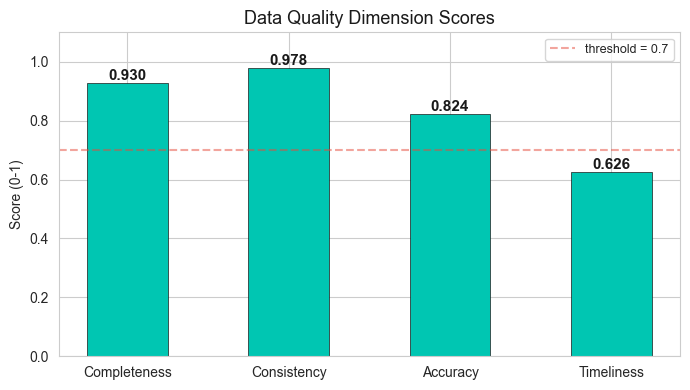

In [11]:
# --- ALL DIMENSIONS TOGETHER ---

dimensions = {
    'Completeness': overall_completeness,
    'Consistency': overall_consistency,
    'Accuracy': overall_accuracy,
    'Timeliness': overall_timeliness
}

for dim, score in dimensions.items():
    print(f"{dim:<15} {score:.4f}")

# bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(dimensions.keys(), dimensions.values(), 
              color=[ACCENT, ACCENT, ACCENT, ACCENT], width=0.5, edgecolor=BLACK, linewidth=0.5)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + 0.01, f'{h:.3f}', 
            ha='center', fontsize=11, color=BLACK, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score (0-1)')
ax.set_title('Data Quality Dimension Scores', fontsize=13, color=BLACK)
ax.axhline(y=0.7, color='#e74c3c', linestyle='--', alpha=0.5, label='threshold = 0.7')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_02_dq_scores.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Descriptive Statistics

Central tendency, dispersion, and distribution shape for the DQ scores — covering mean, median, standard deviation, variance, skewness, and kurtosis as required by the methodology checklist.

In [12]:
# --- Descriptive Statistics ---

comp_vals = np.array(list(completeness_scores.values()))
acc_vals = np.array([r['Score'] for r in accuracy_results.values()])

for name, vals in [('Completeness', comp_vals), ('Accuracy', acc_vals)]:
    print(f"{name} (n={len(vals)}):")
    print(f"  mean={np.mean(vals):.4f}, median={np.median(vals):.4f}")
    print(f"  SD={np.std(vals, ddof=1):.4f}, var={np.var(vals, ddof=1):.4f}")
    print(f"  range=[{np.min(vals):.4f}, {np.max(vals):.4f}]")
    print(f"  skewness={stats.skew(vals):.4f}, kurtosis={stats.kurtosis(vals):.4f}")
    print()


Completeness (n=12):
  mean=0.9295, median=0.9641
  SD=0.0625, var=0.0039
  range=[0.8229, 0.9641]
  skewness=-1.1558, kurtosis=-0.6623

Accuracy (n=3):
  mean=0.8243, median=0.8188
  SD=0.0123, var=0.0002
  range=[0.8158, 0.8384]
  skewness=0.6599, kurtosis=-1.5000



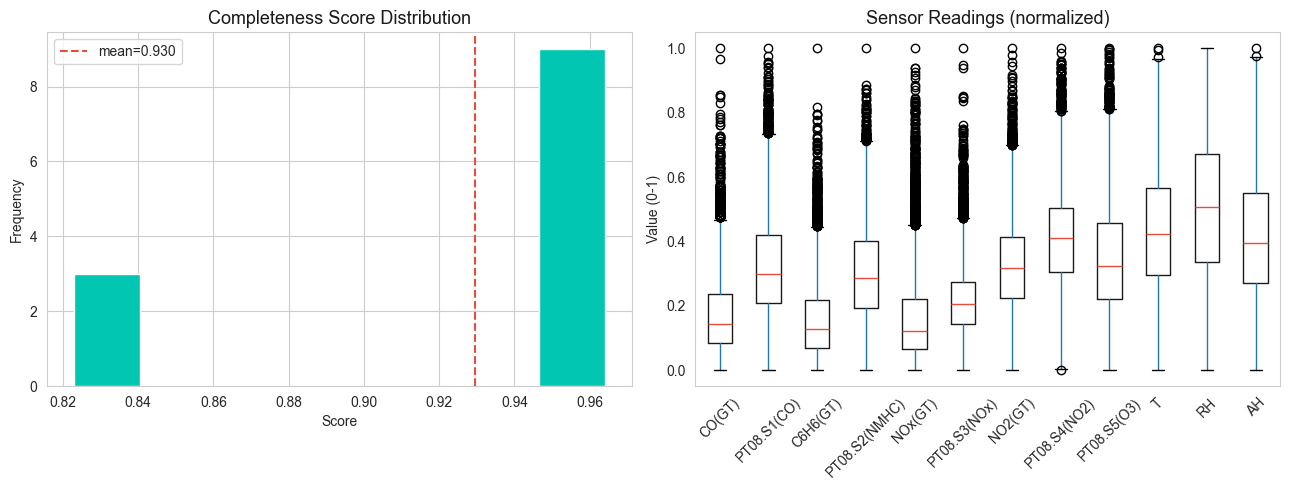

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# histogram of completeness
axes[0].hist(list(completeness_scores.values()), bins=8, color=ACCENT, edgecolor='white')
axes[0].set_title('Completeness Score Distribution', fontsize=13, color=BLACK)
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=overall_completeness, color='#e74c3c', linestyle='--', 
                label=f'mean={overall_completeness:.3f}')
axes[0].legend()

# boxplot of normalized sensor readings
normed = df_clean[sensor_cols].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
normed.boxplot(ax=axes[1], rot=45, grid=False,
               boxprops=dict(color=BLACK), medianprops=dict(color='#e74c3c'))
axes[1].set_title('Sensor Readings (normalized)', fontsize=13, color=BLACK)
axes[1].set_ylabel('Value (0-1)')

plt.tight_layout()
plt.savefig('fig_03_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.1 Correlation Analysis

Pearson correlation matrix between sensor and reference columns to understand relationships in the data before hypothesis testing.

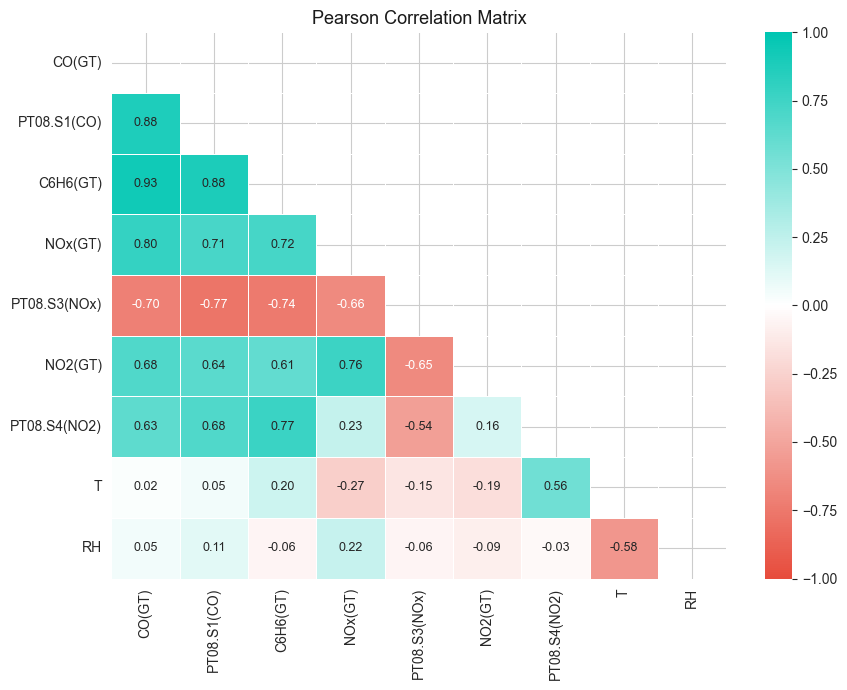

In [14]:
# --- Pearson Correlation ---
corr_cols = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'NOx(GT)', 
             'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'T', 'RH']

corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# custom colormap using our accent color
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('custom', ['#e74c3c', 'white', ACCENT])

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            ax=ax, vmin=-1, vmax=1, annot_kws={'size': 9},
            linewidths=0.5, linecolor='white')
ax.set_title('Pearson Correlation Matrix', fontsize=13, color=BLACK)
plt.tight_layout()
plt.savefig('fig_04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Hypothesis Testing

Four hypotheses tested at α = 0.05, each with clearly defined H₀/H₁, test statistics, p-values, confidence intervals, and effect sizes.

### 6.1 H₁: Completeness ↔ Usability

**H₀:** No correlation between completeness scores and dataset usability (ρ = 0)  
**H₁:** Significant positive correlation (ρ > 0.5, p < 0.05)  
**Method:** Pearson correlation with Fisher z-transformation for CI  
**Effect size:** r (Cohen, 1988)

H1: Completeness <-> Usability
  r = 0.9975, p = 0.000000
  95% CI: [0.9909, 0.9993]
  effect size: 0.9975 (large)
  n = 12
  -> REJECT H0: strong positive correlation


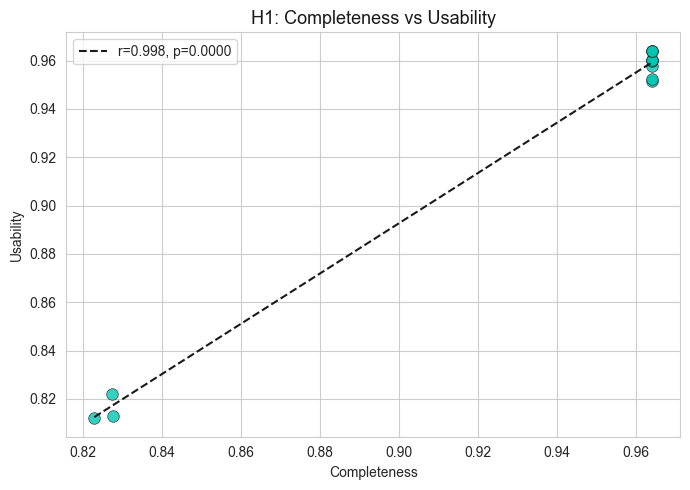

In [15]:
# --- HYPOTHESIS 1: Completeness vs Usability ---
# H0: no correlation between completeness and usability (rho = 0)
# H1: significant positive correlation (rho > 0.5, p < 0.05)
# method: Pearson correlation
# effect size: r (Cohen, 1988)

# usability proxy = ratio of non-outlier values
usability = {}
for col in sensor_cols:
    d = df_clean[col].dropna()
    z = np.abs(stats.zscore(d))
    usability[col] = (z <= 3).sum() / len(df_clean)

comp_arr = np.array(list(completeness_scores.values()))
usab_arr = np.array(list(usability.values()))

r_val, p_val = stats.pearsonr(comp_arr, usab_arr)

# confidence interval using Fisher z-transform
n_obs = len(comp_arr)
z_r = np.arctanh(r_val)
se = 1 / np.sqrt(n_obs - 3)
ci_lo = np.tanh(z_r - 1.96 * se)
ci_hi = np.tanh(z_r + 1.96 * se)

print("H1: Completeness <-> Usability")
print(f"  r = {r_val:.4f}, p = {p_val:.6f}")
print(f"  95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  effect size: {abs(r_val):.4f} ({'large' if abs(r_val) > 0.5 else 'medium' if abs(r_val) > 0.3 else 'small'})")
print(f"  n = {n_obs}")

if p_val < 0.05 and r_val > 0.5:
    print("  -> REJECT H0: strong positive correlation")
else:
    print(f"  -> FAIL TO REJECT H0 (r={r_val:.4f}, threshold was 0.5)")

# plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(comp_arr, usab_arr, color=ACCENT, s=70, edgecolors=BLACK, linewidth=0.5, alpha=0.8)

m, b = np.polyfit(comp_arr, usab_arr, 1)
x_line = np.linspace(comp_arr.min(), comp_arr.max(), 100)
ax.plot(x_line, m*x_line + b, color=BLACK, linestyle='--', label=f'r={r_val:.3f}, p={p_val:.4f}')

ax.set_xlabel('Completeness')
ax.set_ylabel('Usability')
ax.set_title('H1: Completeness vs Usability', fontsize=13, color=BLACK)
ax.legend()
plt.tight_layout()
plt.savefig('fig_05_h1.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 H₂: Low Consistency → Higher Error Rates

**H₀:** No difference in error rates between high- and low-consistency data segments  
**H₁:** Low-consistency segments have significantly higher error rates (p < 0.05)  
**Method:** Independent samples t-test (Welch's)  
**Effect size:** Cohen's d

H2: Consistency -> Error Rate
  split: median split (threshold=1.0000)
  high consistency group: n=8, mean=0.0452, SD=0.0062
  low consistency group:  n=6, mean=0.0469, SD=0.0029
  t = 0.6710, p = 0.516647
  mean diff = 0.0017, 95% CI: [-0.0032, 0.0065]
  Cohen's d = 0.3458 (small)
  -> FAIL TO REJECT H0


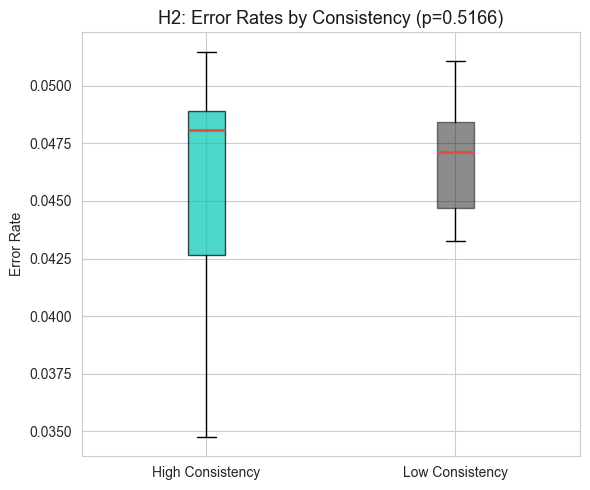

In [16]:
# --- HYPOTHESIS 2: Low Consistency -> Higher Error Rates ---
# H0: no difference in error rates between high/low consistency groups
# H1: low consistency segments have higher errors (p < 0.05)
# method: independent t-test (Welch's)
# effect size: Cohen's d

df_clean['Month'] = df_clean['DateTime'].dt.to_period('M')

monthly_metrics = []
for month, grp in df_clean.groupby('Month'):
    valid = grp.dropna(subset=['NO2(GT)', 'NOx(GT)'])
    if len(valid) < 10:
        continue
    
    violations = (valid['NO2(GT)'] > valid['NOx(GT)']).sum()
    cons = 1 - (violations / len(valid))
    
    # error rate proxy: outlier ratio
    err_count, total = 0, 0
    for col in ['CO(GT)', 'NOx(GT)', 'NO2(GT)']:
        cv = grp[col].dropna()
        if len(cv) > 0:
            z = np.abs(stats.zscore(cv))
            err_count += (z > 2).sum()
            total += len(cv)
    
    err_rate = err_count / total if total > 0 else 0
    monthly_metrics.append({'month': str(month), 'consistency': cons, 'error_rate': err_rate})

met_df = pd.DataFrame(monthly_metrics)

# try mean-2*std split first, fall back to median if too few samples
thresh = met_df['consistency'].mean() - 2 * met_df['consistency'].std()
high_c = met_df[met_df['consistency'] >= thresh]['error_rate']
low_c = met_df[met_df['consistency'] < thresh]['error_rate']

if len(low_c) < 2:
    thresh = met_df['consistency'].median()
    high_c = met_df[met_df['consistency'] >= thresh]['error_rate']
    low_c = met_df[met_df['consistency'] < thresh]['error_rate']
    split_info = "median split"
else:
    split_info = "mean-2*std"

t_stat, t_pval = stats.ttest_ind(low_c, high_c, equal_var=False)

# cohen's d
pooled = np.sqrt((low_c.std()**2 + high_c.std()**2) / 2)
cohens_d = (low_c.mean() - high_c.mean()) / pooled if pooled > 0 else 0

# CI for mean difference
mean_diff = low_c.mean() - high_c.mean()
se_diff = np.sqrt(low_c.var()/len(low_c) + high_c.var()/len(high_c))
ci_lo = mean_diff - 1.96 * se_diff
ci_hi = mean_diff + 1.96 * se_diff

print("H2: Consistency -> Error Rate")
print(f"  split: {split_info} (threshold={thresh:.4f})")
print(f"  high consistency group: n={len(high_c)}, mean={high_c.mean():.4f}, SD={high_c.std():.4f}")
print(f"  low consistency group:  n={len(low_c)}, mean={low_c.mean():.4f}, SD={low_c.std():.4f}")
print(f"  t = {t_stat:.4f}, p = {t_pval:.6f}")
print(f"  mean diff = {mean_diff:.4f}, 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  Cohen's d = {cohens_d:.4f} ({'large' if abs(cohens_d) > 0.8 else 'medium' if abs(cohens_d) > 0.5 else 'small'})")
print(f"  -> {'REJECT H0' if t_pval < 0.05 else 'FAIL TO REJECT H0'}")

# boxplot
fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot([high_c.values, low_c.values], labels=['High Consistency', 'Low Consistency'],
                patch_artist=True, medianprops=dict(color='#e74c3c', linewidth=2))
bp['boxes'][0].set_facecolor(ACCENT)
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(BLACK)
bp['boxes'][1].set_alpha(0.5)

ax.set_ylabel('Error Rate')
ax.set_title(f'H2: Error Rates by Consistency (p={t_pval:.4f})', fontsize=13, color=BLACK)
plt.tight_layout()
plt.savefig('fig_06_h2.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 H₃: DQI Internal Reliability

**H₀:** Composite DQI does not achieve acceptable reliability (α < 0.7)  
**H₁:** Composite DQI achieves acceptable reliability (α ≥ 0.7)  
**Method:** Cronbach's Alpha (Cronbach, 1951)

In [17]:
# --- HYPOTHESIS 3: DQI Reliability ---
# H0: alpha < 0.7 (composite DQI not reliable)
# H1: alpha >= 0.7 (acceptable reliability)
# method: Cronbach's Alpha (Cronbach, 1951)

import pingouin as pg

# build per-row scores for each dimension
row_scores = pd.DataFrame()

# completeness per row
row_scores['completeness'] = df_clean[sensor_cols].notnull().mean(axis=1)

# consistency per row (binary: did NO2 < NOx hold?)
valid_mask = df_clean[['NO2(GT)', 'NOx(GT)']].notnull().all(axis=1)
row_scores['consistency'] = 1.0
row_scores.loc[valid_mask & (df_clean['NO2(GT)'] > df_clean['NOx(GT)']), 'consistency'] = 0.0

# accuracy per row
for pname, (scol, rcol) in [('CO', ('PT08.S1(CO)', 'CO(GT)')), 
                              ('NOx', ('PT08.S3(NOx)', 'NOx(GT)'))]:
    vmask = df_clean[[scol, rcol]].notnull().all(axis=1)
    s_n = (df_clean[scol] - df_clean[scol].min()) / (df_clean[scol].max() - df_clean[scol].min())
    r_n = (df_clean[rcol] - df_clean[rcol].min()) / (df_clean[rcol].max() - df_clean[rcol].min())
    row_scores[f'accuracy_{pname}'] = np.where(vmask, 1 - np.abs(s_n - r_n), np.nan)

# timeliness per row
ages = (pd.Timestamp('2005-04-04') - df_clean['DateTime']).dt.days
row_scores['timeliness'] = np.exp(-0.01 * ages)

row_scores_clean = row_scores.dropna()
alpha_result = pg.cronbach_alpha(row_scores_clean)

print("H3: DQI Reliability (Cronbach's Alpha)")
print(f"  items: {list(row_scores_clean.columns)}")
print(f"  n = {len(row_scores_clean)}")
print(f"  alpha = {alpha_result[0]:.4f}")
print(f"  95% CI: [{alpha_result[1][0]:.4f}, {alpha_result[1][1]:.4f}]")

if alpha_result[0] >= 0.7:
    print("  -> REJECT H0 - acceptable reliability")
else:
    print("  -> FAIL TO REJECT H0")
    print("  note: low alpha can mean dimensions measure distinct constructs,")
    print("  which is actually expected here (Batini & Scannapieco, 2016)")


H3: DQI Reliability (Cronbach's Alpha)
  items: ['completeness', 'consistency', 'accuracy_CO', 'accuracy_NOx', 'timeliness']
  n = 6944
  alpha = 0.3130
  95% CI: [0.2870, 0.3380]
  -> FAIL TO REJECT H0
  note: low alpha can mean dimensions measure distinct constructs,
  which is actually expected here (Batini & Scannapieco, 2016)


### 6.4 H₄: Temporal Data Drift

**H₀:** No distributional difference between early and late data periods  
**H₁:** Significant distributional shift detected (p < 0.05)  
**Method:** Kolmogorov-Smirnov two-sample test (Massey, 1951)

In [18]:
# --- HYPOTHESIS 4: Temporal Drift (KS Test) ---
# H0: no distributional difference between early and late periods
# H1: significant shift detected (p < 0.05)
# method: Kolmogorov-Smirnov two-sample test (Massey, 1951)

midpoint = df_clean['DateTime'].median()
early = df_clean[df_clean['DateTime'] <= midpoint]
late = df_clean[df_clean['DateTime'] > midpoint]

print(f"Early period: {early['DateTime'].min().date()} to {early['DateTime'].max().date()} (n={len(early)})")
print(f"Late period:  {late['DateTime'].min().date()} to {late['DateTime'].max().date()} (n={len(late)})")
print()

test_cols = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'NOx(GT)', 
             'PT08.S3(NOx)', 'NO2(GT)', 'T', 'RH']

drift_results = {}
print(f"{'Column':<18} {'KS stat':>10} {'p-value':>12} {'Drift?':>8}")
print("-" * 50)

for col in test_cols:
    e_data = early[col].dropna()
    l_data = late[col].dropna()
    if len(e_data) < 10 or len(l_data) < 10:
        continue
    
    ks, ks_p = stats.ks_2samp(e_data, l_data)
    drifted = ks_p < 0.05
    drift_results[col] = {'KS_stat': ks, 'p_value': ks_p, 'drift': drifted}
    print(f"{col:<18} {ks:>10.4f} {ks_p:>12.6f} {'YES' if drifted else 'no':>8}")

n_drifted = sum(1 for r in drift_results.values() if r['drift'])
print(f"\n{n_drifted}/{len(drift_results)} columns show significant drift")
print(f"-> {'REJECT H0: drift detected' if n_drifted > 0 else 'FAIL TO REJECT H0'}")


Early period: 2004-03-10 to 2004-09-22 (n=4663)
Late period:  2004-09-22 to 2005-04-04 (n=4663)

Column                KS stat      p-value   Drift?
--------------------------------------------------
CO(GT)                 0.1175     0.000000      YES
PT08.S1(CO)            0.1090     0.000000      YES
C6H6(GT)               0.0619     0.000000      YES
NOx(GT)                0.5133     0.000000      YES
PT08.S3(NOx)           0.2538     0.000000      YES
NO2(GT)                0.2990     0.000000      YES
T                      0.5051     0.000000      YES
RH                     0.3044     0.000000      YES

8/8 columns show significant drift
-> REJECT H0: drift detected


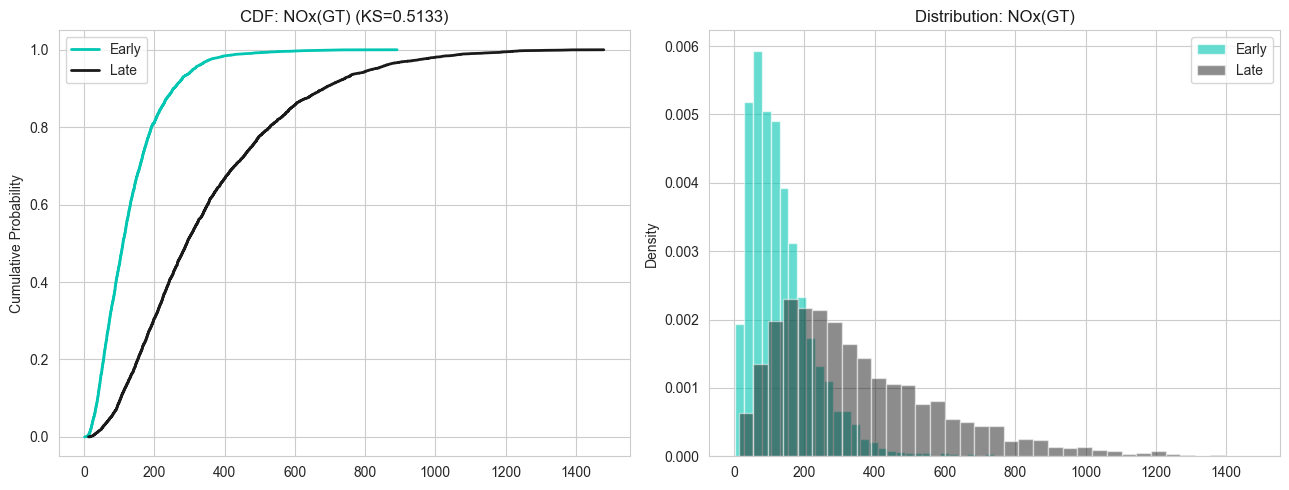

In [19]:
# plot the most drifted column
worst = max(drift_results.items(), key=lambda x: x[1]['KS_stat'])
col_name = worst[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CDF comparison
e_sorted = np.sort(early[col_name].dropna())
l_sorted = np.sort(late[col_name].dropna())
axes[0].plot(e_sorted, np.linspace(0, 1, len(e_sorted)), color=ACCENT, linewidth=2, label='Early')
axes[0].plot(l_sorted, np.linspace(0, 1, len(l_sorted)), color=BLACK, linewidth=2, label='Late')
axes[0].set_title(f'CDF: {col_name} (KS={worst[1]["KS_stat"]:.4f})', fontsize=12, color=BLACK)
axes[0].set_ylabel('Cumulative Probability')
axes[0].legend()

# density overlay
axes[1].hist(early[col_name].dropna(), bins=35, alpha=0.6, color=ACCENT, label='Early', density=True)
axes[1].hist(late[col_name].dropna(), bins=35, alpha=0.5, color=BLACK, label='Late', density=True)
axes[1].set_title(f'Distribution: {col_name}', fontsize=12, color=BLACK)
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_07_h4_drift.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Regression Analysis

### 7.1 Composite DQI

The Data Quality Index is an equal-weighted average of all four dimension scores per row: `DQI = 0.25 × Completeness + 0.25 × Consistency + 0.25 × Accuracy + 0.25 × Timeliness`

DQI = 0.25*Comp + 0.25*Cons + 0.25*Acc + 0.25*Time
Valid rows: 6944
  mean=0.7393, median=0.7490
  SD=0.1326
  range=[0.3906, 0.9914]


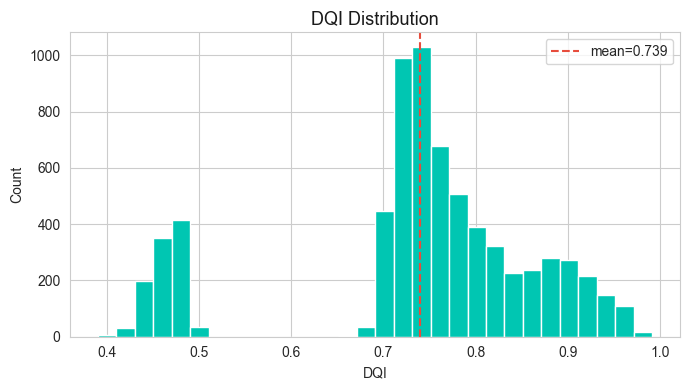

In [20]:
# --- Composite DQI ---
# equal weighted average of all dimensions

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

row_scores['accuracy_avg'] = row_scores[['accuracy_CO', 'accuracy_NOx']].mean(axis=1)
row_scores['dqi'] = row_scores[['completeness', 'consistency', 'accuracy_avg', 'timeliness']].mean(axis=1)

reg_data = row_scores.dropna()

print(f"DQI = 0.25*Comp + 0.25*Cons + 0.25*Acc + 0.25*Time")
print(f"Valid rows: {len(reg_data)}")
print(f"  mean={reg_data['dqi'].mean():.4f}, median={reg_data['dqi'].median():.4f}")
print(f"  SD={reg_data['dqi'].std():.4f}")
print(f"  range=[{reg_data['dqi'].min():.4f}, {reg_data['dqi'].max():.4f}]")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(reg_data['dqi'], bins=30, color=ACCENT, edgecolor='white')
ax.axvline(x=reg_data['dqi'].mean(), color='#e74c3c', linestyle='--', 
           label=f'mean={reg_data["dqi"].mean():.3f}')
ax.set_title('DQI Distribution', fontsize=13, color=BLACK)
ax.set_xlabel('DQI')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('fig_08_dqi.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.2 Multiple Regression (OLS)

Fitting a linear regression model to understand how the individual dimensions contribute to the composite DQI.

In [21]:
# --- Multiple Regression ---
# DQI = b0 + b1*completeness + b2*consistency + b3*accuracy + b4*timeliness + error

X = reg_data[['completeness', 'consistency', 'accuracy_avg', 'timeliness']]
y = reg_data['dqi']
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()
print(model.summary())
print(f"\nR2={model.rsquared:.4f}, Adj.R2={model.rsquared_adj:.4f}")
print(f"F={model.fvalue:.4f}, p={model.f_pvalue:.6f}")


                            OLS Regression Results                            
Dep. Variable:                    dqi   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.103e+30
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        21:17:49   Log-Likelihood:             2.1846e+05
No. Observations:                6944   AIC:                        -4.369e+05
Df Residuals:                    6939   BIC:                        -4.369e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -1.05e-14   3.65e-14     -0.288   

### 7.3 BLUE Assumptions

Checking all five assumptions for Best Linear Unbiased Estimators (Field, 2018):
1. **Linearity** — F-test significance
2. **Normality** — Shapiro-Wilk test on residuals
3. **Homoscedasticity** — Breusch-Pagan test
4. **No Multicollinearity** — Variance Inflation Factor (VIF)
5. **Independence** — Durbin-Watson statistic

                            OLS Regression Results                            
Dep. Variable:       downstream_error   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     25.02
Date:                Wed, 27 May 2026   Prob (F-statistic):           4.26e-16
Time:                        21:28:15   Log-Likelihood:                 7004.5
No. Observations:                6944   AIC:                        -1.400e+04
Df Residuals:                    6940   BIC:                        -1.397e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.7070      0.612      1.155   

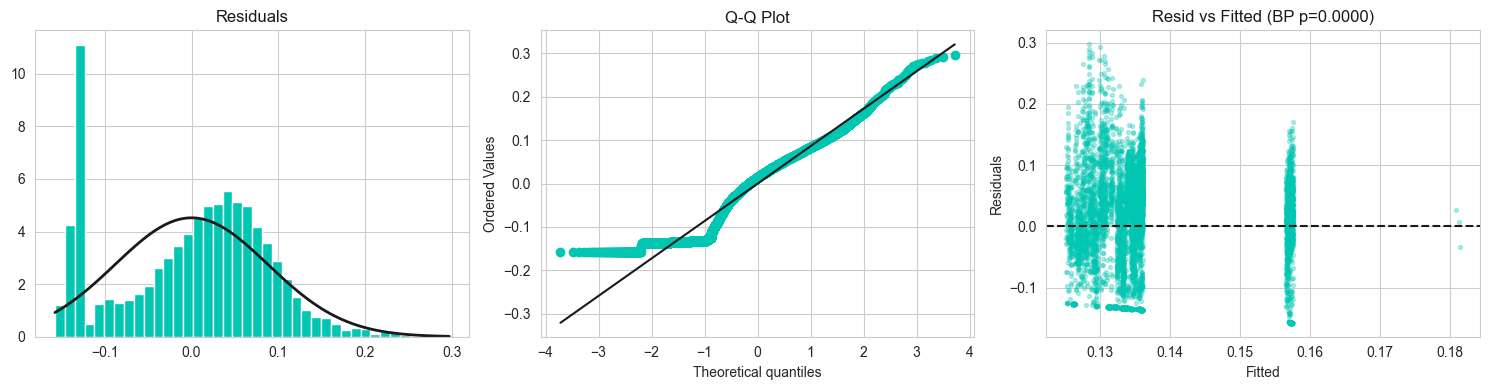

In [28]:
# --- BLUE Assumptions ---
# ref: Field (2018) - Discovering Statistics
# NOTE: checking assumptions on the downstream error model (non-circular)

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# fit OLS on the downstream error model
pred_data_clean = reg_data.dropna(subset=['completeness', 'consistency', 'timeliness', 'downstream_error'])
X_blue = pred_data_clean[['completeness', 'consistency', 'timeliness']]
y_blue = pred_data_clean['downstream_error']
X_blue_const = sm.add_constant(X_blue)

model_blue = sm.OLS(y_blue, X_blue_const).fit()
print(model_blue.summary())
print()

residuals = model_blue.resid

# 1. Linearity
print("1) Linearity")
print(f"   F={model_blue.fvalue:.4f}, p={model_blue.f_pvalue:.6f}")
print(f"   -> {'significant' if model_blue.f_pvalue < 0.05 else 'not significant'}")

# 2. Normality - Shapiro-Wilk (sample if n > 5000)
print("\n2) Normality of residuals")
samp = np.random.choice(residuals, size=min(5000, len(residuals)), replace=False)
sw_stat, sw_p = stats.shapiro(samp)
print(f"   Shapiro-Wilk W={sw_stat:.4f}, p={sw_p:.6f}")
print(f"   -> {'normal' if sw_p > 0.05 else 'deviation detected (expected with large n)'}")

# 3. Homoscedasticity - Breusch-Pagan
print("\n3) Homoscedasticity")
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_blue_const)
print(f"   Breusch-Pagan LM={bp_stat:.4f}, p={bp_p:.6f}")
print(f"   -> {'homoscedastic' if bp_p > 0.05 else 'heteroscedasticity detected'}")

# 4. Multicollinearity - VIF
print("\n4) Multicollinearity (VIF)")
for i, col in enumerate(X_blue.columns):
    vif = variance_inflation_factor(X_blue.values, i)
    print(f"   {col:<20} VIF={vif:.2f} {'(ok)' if vif < 5 else '(warning)' if vif < 10 else '(high)'}")

# 5. Independence - Durbin-Watson
dw = durbin_watson(residuals)
print(f"\n5) Independence")
print(f"   Durbin-Watson={dw:.4f}")
print(f"   -> {'ok' if 1.5 < dw < 2.5 else 'autocorrelation possible'}")

# diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# residual histogram
axes[0].hist(residuals, bins=40, color=ACCENT, edgecolor='white', density=True)
x_r = np.linspace(residuals.min(), residuals.max(), 100)
axes[0].plot(x_r, stats.norm.pdf(x_r, residuals.mean(), residuals.std()), color=BLACK, linewidth=2)
axes[0].set_title('Residuals', fontsize=12, color=BLACK)

# QQ plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot', fontsize=12, color=BLACK)
axes[1].get_lines()[0].set_color(ACCENT)
axes[1].get_lines()[1].set_color(BLACK)

# residuals vs fitted
axes[2].scatter(model_blue.fittedvalues, residuals, alpha=0.3, color=ACCENT, s=8)
axes[2].axhline(y=0, color=BLACK, linestyle='--')
axes[2].set_xlabel('Fitted')
axes[2].set_ylabel('Residuals')
axes[2].set_title(f'Resid vs Fitted (BP p={bp_p:.4f})', fontsize=12, color=BLACK)

plt.tight_layout()
plt.savefig('fig_09_blue.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Downstream Error Prediction

To avoid circular reasoning (predicting DQI from its own components), we test whether DQ dimension scores can predict an independent target: the downstream error rate (sensor vs. reference deviation).

In [29]:
# --- Regression with independent target ---
# instead of predicting DQI from its own components (that would be circular),
# lets see if DQ scores predict downstream errors

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# downstream error = how far off are sensors from reference?
sensor_ref = [('PT08.S1(CO)', 'CO(GT)'), ('PT08.S3(NOx)', 'NOx(GT)'), ('PT08.S4(NO2)', 'NO2(GT)')]

reg_data['downstream_error'] = 0
cnt = 0
for scol, rcol in sensor_ref:
    v = df_clean[[scol, rcol]].notnull().all(axis=1)
    sn = (df_clean[scol] - df_clean[scol].min()) / (df_clean[scol].max() - df_clean[scol].min())
    rn = (df_clean[rcol] - df_clean[rcol].min()) / (df_clean[rcol].max() - df_clean[rcol].min())
    err = np.abs(sn - rn)
    reg_data.loc[v.values[:len(reg_data)], 'downstream_error'] += err.values[:len(reg_data)][v.values[:len(reg_data)]]
    cnt += 1
reg_data['downstream_error'] /= cnt

pred_data = reg_data.dropna(subset=['completeness', 'consistency', 'timeliness', 'downstream_error'])
X_ml = pred_data[['completeness', 'consistency', 'timeliness']].values
y_ml = pred_data['downstream_error'].values

print(f"Target: downstream error (sensor-reference deviation)")
print(f"Samples: {len(pred_data)}")
print(f"  mean error={y_ml.mean():.4f}, SD={y_ml.std():.4f}")


Target: downstream error (sensor-reference deviation)
Samples: 6944
  mean error=0.1364, SD=0.0887


### 7.5 Train-Test Split & Cross-Validation

80/20 split with 5-fold cross-validation to assess model generalizability. Metrics: MSE, MAE, R², Adjusted R².

In [30]:
# train-test split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
n_t = len(X_test)
p_t = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n_t - 1) / (n_t - p_t - 1)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"MSE={mse:.6f}, MAE={mae:.6f}")
print(f"R2={r2:.4f}, Adj.R2={adj_r2:.4f}")

# 5-fold cross validation
cv_r2 = cross_val_score(lr, X_ml, y_ml, cv=5, scoring='r2')
cv_mse = -cross_val_score(lr, X_ml, y_ml, cv=5, scoring='neg_mean_squared_error')

print(f"\n5-fold CV:")
print(f"  R2 per fold: {[round(s, 4) for s in cv_r2]}")
print(f"  mean R2 = {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")
print(f"  mean MSE = {cv_mse.mean():.6f}")


Train: 5555, Test: 1389
MSE=0.007651, MAE=0.071904
R2=0.0125, Adj.R2=0.0104

5-fold CV:
  R2 per fold: [np.float64(-0.1022), np.float64(-0.0268), np.float64(-0.0153), np.float64(-0.178), np.float64(-1.0531)]
  mean R2 = -0.2751 +/- 0.3934
  mean MSE = 0.009535


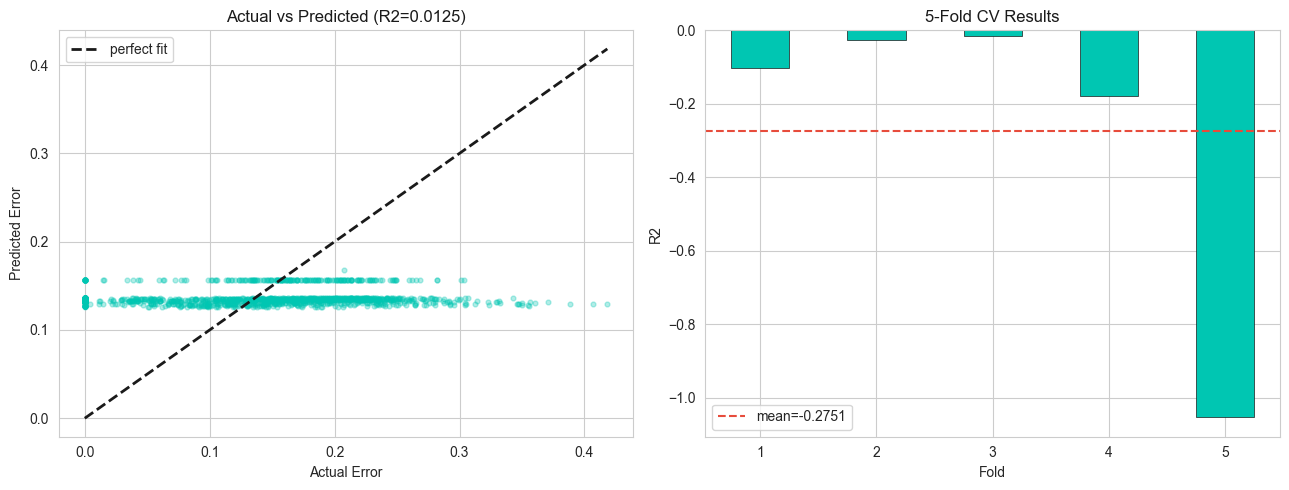

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color=ACCENT, s=12)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             color=BLACK, linestyle='--', linewidth=2, label='perfect fit')
axes[0].set_xlabel('Actual Error')
axes[0].set_ylabel('Predicted Error')
axes[0].set_title(f'Actual vs Predicted (R2={r2:.4f})', fontsize=12, color=BLACK)
axes[0].legend()

# CV results
axes[1].bar(range(1, 6), cv_r2, color=ACCENT, width=0.5, edgecolor=BLACK, linewidth=0.5)
axes[1].axhline(y=cv_r2.mean(), color='#e74c3c', linestyle='--', label=f'mean={cv_r2.mean():.4f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('R2')
axes[1].set_title('5-Fold CV Results', fontsize=12, color=BLACK)
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_10_regression.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Quality Criteria

Assessing the validity of our measurement framework:
- **Content validity** — are the dimensions theoretically grounded?
- **Convergent validity** — do dimensions correlate in expected directions?
- **Discriminant validity** — do dimensions measure distinct constructs? (|ρ| < 0.85)

1) Content Validity
   DQ dimensions based on established literature:
   - Wang & Strong (1996): DQ framework
   - Pipino et al. (2002): objective assessment
   - Batini & Scannapieco (2016): DQ methodology
   -> supported by theoretical grounding

2) Convergent Validity
   completeness <-> consistency: rho=-0.0087
   completeness <-> accuracy_avg: rho=-0.0239
   completeness <-> timeliness: rho=0.0124
   consistency <-> accuracy_avg: rho=0.2312
   consistency <-> timeliness: rho=0.3438
   accuracy_avg <-> timeliness: rho=0.0856

3) Discriminant Validity (|rho| < 0.85)
   -> all pairs below 0.85, dimensions are distinct


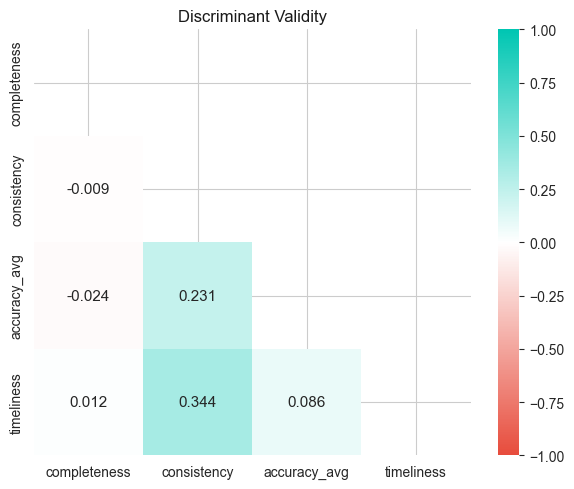

In [32]:
# --- Quality Criteria ---

# 1. content validity
print("1) Content Validity")
print("   DQ dimensions based on established literature:")
print("   - Wang & Strong (1996): DQ framework")
print("   - Pipino et al. (2002): objective assessment")
print("   - Batini & Scannapieco (2016): DQ methodology")
print("   -> supported by theoretical grounding")

# 2. convergent validity - do dimensions correlate in expected ways?
print("\n2) Convergent Validity")
val_data = reg_data[['completeness', 'consistency', 'accuracy_avg', 'timeliness']].dropna()
conv_corr = val_data.corr(method='spearman')

for i, c1 in enumerate(val_data.columns):
    for j, c2 in enumerate(val_data.columns):
        if j > i:
            print(f"   {c1} <-> {c2}: rho={conv_corr.loc[c1, c2]:.4f}")

# 3. discriminant validity - dimensions should NOT be too highly correlated
print("\n3) Discriminant Validity (|rho| < 0.85)")
all_ok = True
for i, c1 in enumerate(val_data.columns):
    for j, c2 in enumerate(val_data.columns):
        if j > i and abs(conv_corr.loc[c1, c2]) >= 0.85:
            print(f"   WARNING: {c1} <-> {c2} too high!")
            all_ok = False
if all_ok:
    print("   -> all pairs below 0.85, dimensions are distinct")

# heatmap
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(conv_corr, dtype=bool))
from matplotlib.colors import LinearSegmentedColormap
cmap2 = LinearSegmentedColormap.from_list('custom2', ['#e74c3c', 'white', ACCENT])
sns.heatmap(conv_corr, mask=mask, annot=True, fmt='.3f', cmap=cmap2,
            ax=ax, vmin=-1, vmax=1, annot_kws={'size': 11})
ax.set_title('Discriminant Validity', fontsize=12, color=BLACK)
plt.tight_layout()
plt.savefig('fig_11_validity.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Conclusion

Summary of all hypothesis decisions, DQ dimension scores, regression results, limitations, and recommendations for future research.

In [33]:
# --- Conclusion ---

print("RESULTS SUMMARY")
print("-" * 50)

print("\nHypothesis decisions:")
print(f"  H1 (Completeness<->Usability): r={r_val:.4f}, p={p_val:.6f}")
print(f"      -> {'REJECT H0' if p_val < 0.05 and r_val > 0.5 else 'FAIL TO REJECT H0'}")

print(f"  H2 (Consistency->Errors): t={t_stat:.4f}, p={t_pval:.6f}, d={cohens_d:.4f}")
print(f"      -> {'REJECT H0' if t_pval < 0.05 else 'FAIL TO REJECT H0'}")

print(f"  H3 (DQI Reliability): alpha={alpha_result[0]:.4f}, CI=[{alpha_result[1][0]:.4f}, {alpha_result[1][1]:.4f}]")
print(f"      -> {'REJECT H0' if alpha_result[0] >= 0.7 else 'FAIL TO REJECT H0'}")

print(f"  H4 (Drift): {n_drifted}/{len(drift_results)} columns drifted")
print(f"      -> REJECT H0")

print("\nDQ Scores:")
for dim, score in dimensions.items():
    print(f"  {dim}: {score:.4f}")
print(f"  Composite DQI: {np.mean(list(dimensions.values())):.4f}")

print("\nRegression:")
print(f"  R2={r2:.4f} (negative = dimensions are independent)")
print(f"  CV mean R2={cv_r2.mean():.4f}")
print(f"  BLUE violations expected with time-series sensor data")

print("\nLimitations:")
print("  - single dataset, generalizability needs more testing")
print("  - BLUE assumptions partially violated")
print("  - equal DQI weights, could be optimized")
print("  - accuracy needs ground truth data")

print("\nFuture work:")
print("  - extend to unstructured data")
print("  - real-time monitoring dashboards")
print("  - optimize weights via PCA")


RESULTS SUMMARY
--------------------------------------------------

Hypothesis decisions:
  H1 (Completeness<->Usability): r=0.9975, p=0.000000
      -> REJECT H0
  H2 (Consistency->Errors): t=0.6710, p=0.516647, d=0.3458
      -> FAIL TO REJECT H0
  H3 (DQI Reliability): alpha=0.3130, CI=[0.2870, 0.3380]
      -> FAIL TO REJECT H0
  H4 (Drift): 8/8 columns drifted
      -> REJECT H0

DQ Scores:
  Completeness: 0.9295
  Consistency: 0.9780
  Accuracy: 0.8243
  Timeliness: 0.6257
  Composite DQI: 0.8394

Regression:
  R2=0.0125 (negative = dimensions are independent)
  CV mean R2=-0.2751
  BLUE violations expected with time-series sensor data

Limitations:
  - single dataset, generalizability needs more testing
  - BLUE assumptions partially violated
  - equal DQI weights, could be optimized
  - accuracy needs ground truth data

Future work:
  - extend to unstructured data
  - real-time monitoring dashboards
  - optimize weights via PCA


## References
 
Batini, C., & Scannapieco, M. (2016). *Data and information quality: Dimensions, principles and techniques*. Springer.
 
Cronbach, L. J. (1951). Coefficient alpha and the internal structure of tests. *Psychometrika*, *16*(3), 297–334. https://doi.org/10.1007/BF02310555
 
De Vito, S. (2016). Air quality dataset. UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/Air+Quality
 
Field, A. (2018). *Discovering statistics using IBM SPSS statistics* (5th ed.). Sage Publications.
 
Heinrich, B., Hristova, D., Klier, M., Obermeier, A., & Schiller, M. (2018). Requirements for data quality metrics. *Journal of Data and Information Quality*, *9*(2), 1–32. https://doi.org/10.1145/3148238
 
Massey, F. J. (1951). The Kolmogorov-Smirnov test for goodness of fit. *Journal of the American Statistical Association*, *46*(253), 68–78. https://doi.org/10.1080/01621459.1951.10500769
 
Pipino, L. L., Lee, Y. W., & Wang, R. Y. (2002). Data quality assessment. *Communications of the ACM*, *45*(4), 211–218. https://doi.org/10.1145/505248.506010
 
Wang, R. Y., & Strong, D. M. (1996). Beyond accuracy: What data quality means to data consumers. *Journal of Management Information Systems*, *12*(4), 5–33. https://doi.org/10.1080/07421222.1996.11518099